In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

Basic Statistics:



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



DF shape: (178, 13)

Chemical makeup of the wines (features): Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

Wine target names: ['class_0' 'class_1' 'class_2']

Any nulls in the dataset?
alcohol                         False
malic_acid                      False
ash                             False
alcalinity_of_ash               False
magnesium                       False
total_phenols                   False
flavanoids                      False
nonflavanoid_phenols            False
proanthocyanins                 False
color_intensity                 False
hue                             False
od280/od315_of_diluted_wines    False
proline                         False
dtype: bool


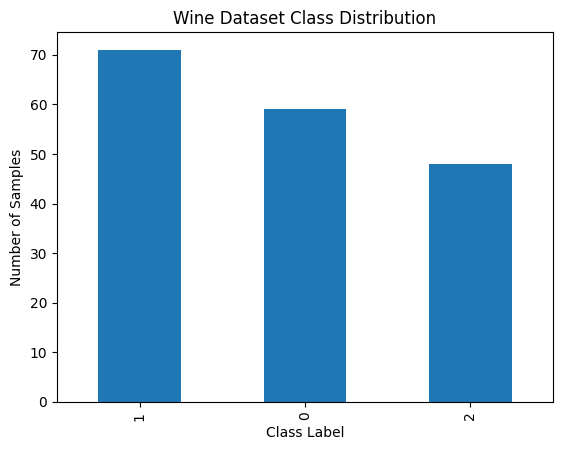

In [ ]:
#Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

#Basic statistics
print("Basic Statistics:")
print()
display(X.describe())
print()
print ("DF shape:", X.shape)
print()
print ("Chemical makeup of the wines (features):",X.columns)
print()
print ("Wine target names:",wine.target_names)
print()
ax = pd.Series(y).value_counts().plot(kind='bar')
ax.set_title("Wine Dataset Class Distribution")
ax.set_xlabel("Class Label")
ax.set_ylabel("Number of Samples")


#Nulls
print("Any nulls in the dataset?")
print(X.isnull().any())

The descriptive statistics summarize the central tendency, dispersion, and distribution of each feature, providing a foundational understanding of the datasets structure. This overview enables identification of potential outliers, scale differences, and anomalous values, and informs preprocessing decisions such as standardization. It ensures that the data is suitable for dimensionality reduction and clustering analysis.

Checking for null values ensures data integrity, prevents algorithmic errors, and avoids bias in statistical and machine learning analyses and most machine learning algorythms cannot work with missing features (Geron, 2019).

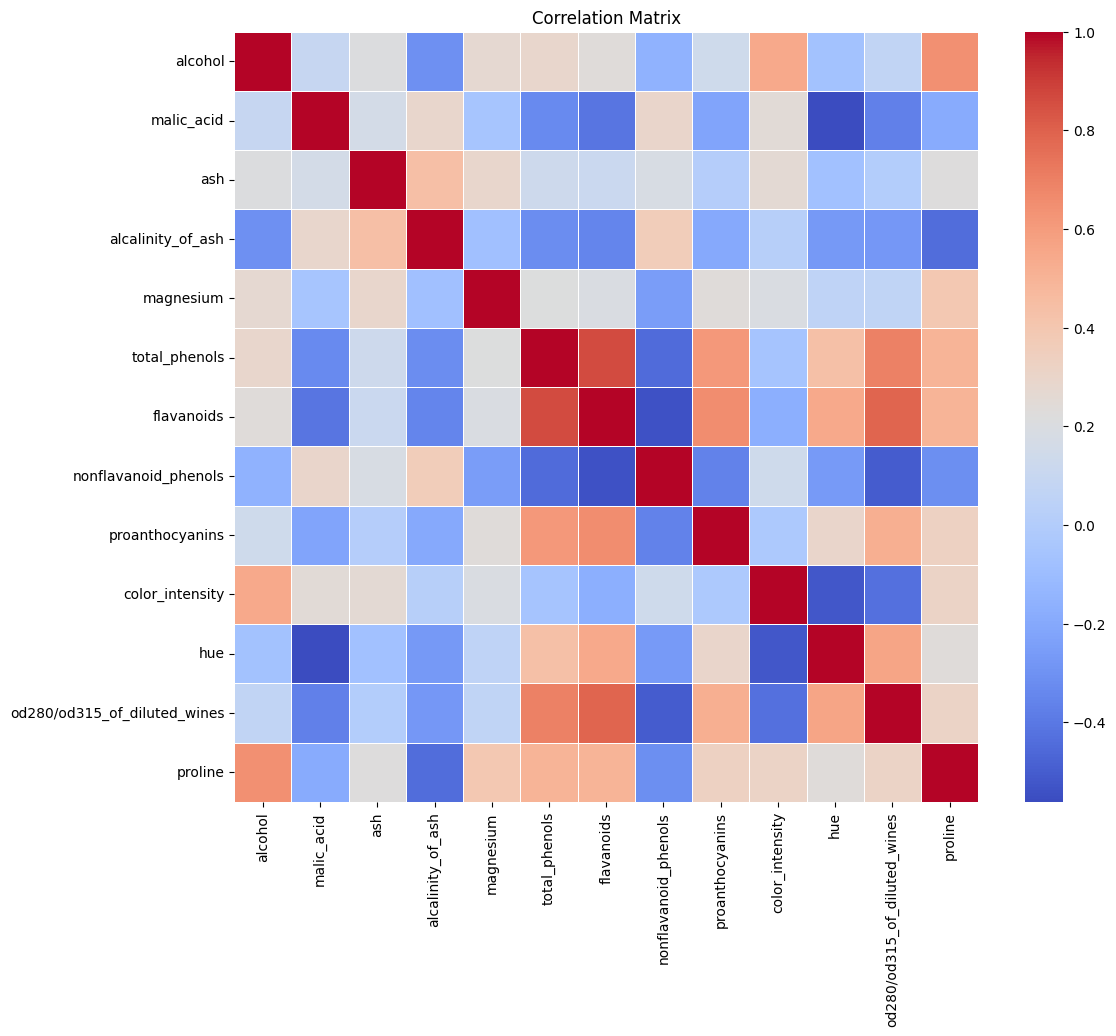

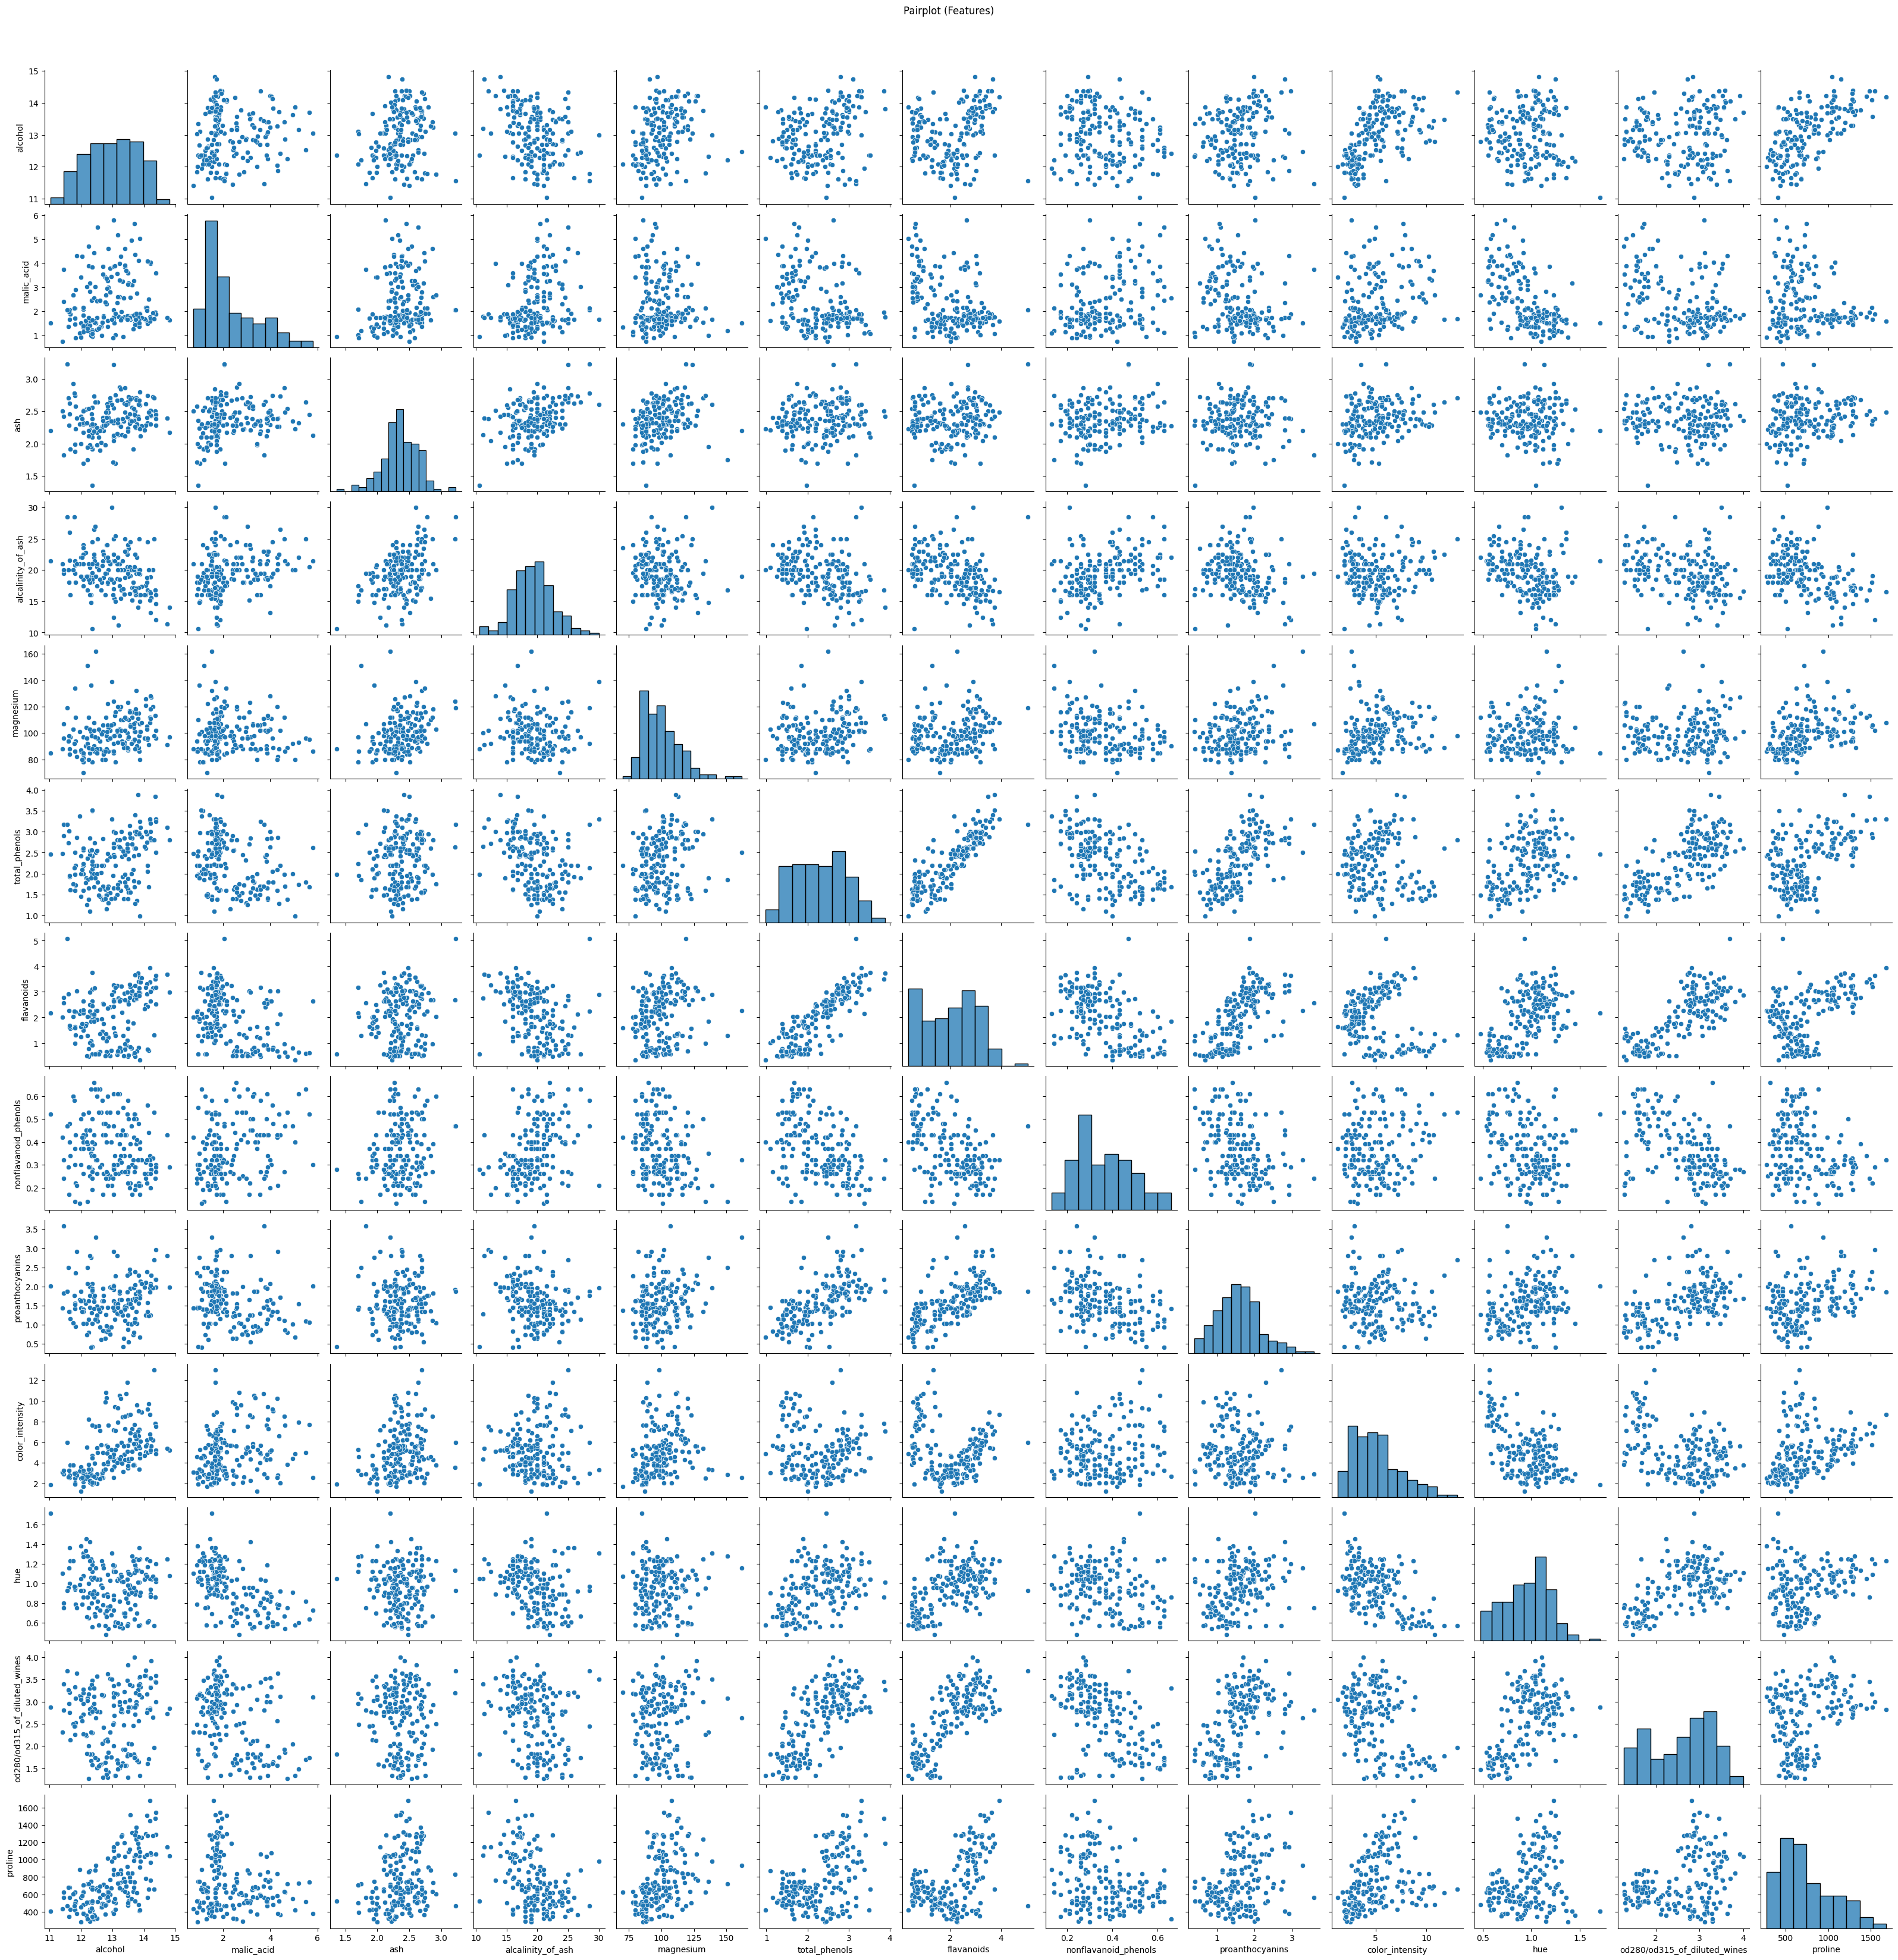

In [ ]:
#Correlation matrix

plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#Pairplot (subset for readability)

sns.pairplot(X.iloc[:, :13])
plt.suptitle("Pairplot (Features)", y=1.02)
plt.show()

Many of the wine features are related to each other, meaning some measurements are telling us similar things. This makes PCA useful because it combines related features into fewer dimensions, and it helps clustering work better.

Explained Variance Ratio:
PC1: 0.3620
PC2: 0.1921
Total Variance (PC1+PC2): 0.5541


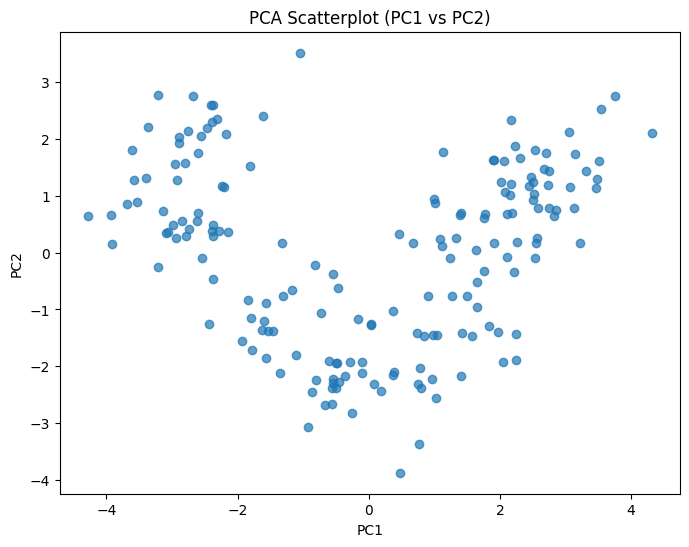

In [ ]:
# =========================
# 2. PCA APPLICATION
# =========================

## Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## Explained variance
explained_var = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"PC1: {explained_var[0]:.4f}")
print(f"PC2: {explained_var[1]:.4f}")
print(f"Total Variance (PC1+PC2): {explained_var.sum():.4f}")

## Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Scatterplot (PC1 vs PC2)")
plt.show()

The first principal component explains 36.20% (lying on the first PC) of the total variance, while the second explains 19.21% (lying along the second PC), resulting in a combined variance capture of 55.41% for the first two components (Geron, 2019). This indicates that more than half of the information in the original high-dimensional dataset is preserved in the two-dimensional PCA representation. While this level of variance retention supports the use of PCA for visualization and clustering, it also implies that some information is distributed across higher-order components, meaning the 2D projection is informative but not fully representative of the complete data structure.

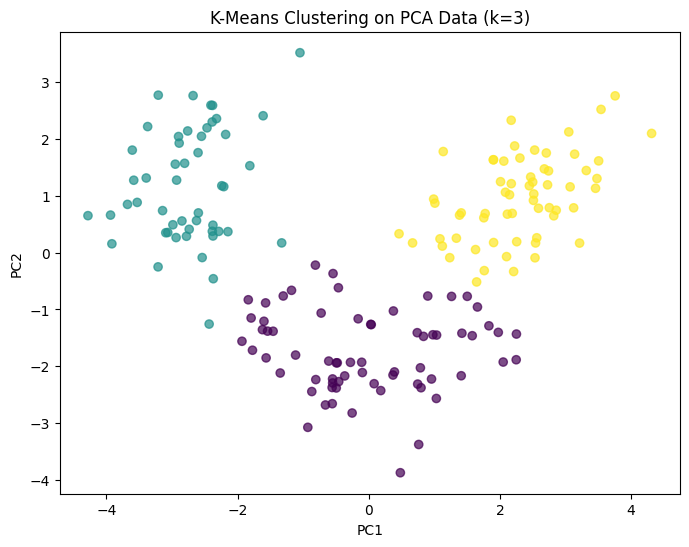

Silhouette Score (k=3): 0.5602


In [ ]:
## KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

## Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA Data (k=3)")
plt.show()

## Silhouette score
sil_score = silhouette_score(X_pca, kmeans_labels)
print(f"Silhouette Score (k=3): {sil_score:.4f}")


A silhouette score of 0.5602 indicates good clustering performance, with strong intra-cluster cohesion and clear inter-cluster separation. This suggests that the k-means model with k = 3 effectively partitions the PCA-reduced data into well-defined groups, with minimal overlap between clusters. The score supports the conclusion that three clusters provide a meaningful and stable segmentation of the dataset.

Overall, the model did a good job grouping similar wines together and separating different types of wines. Most points clearly belong to their cluster rather than being confused between groups.

 The silhouette score is a more precise approach compared to the elbow plot method (but also more computationally expensive). It is the mean silhouette coefficient over all the instances (Geron, 2019).


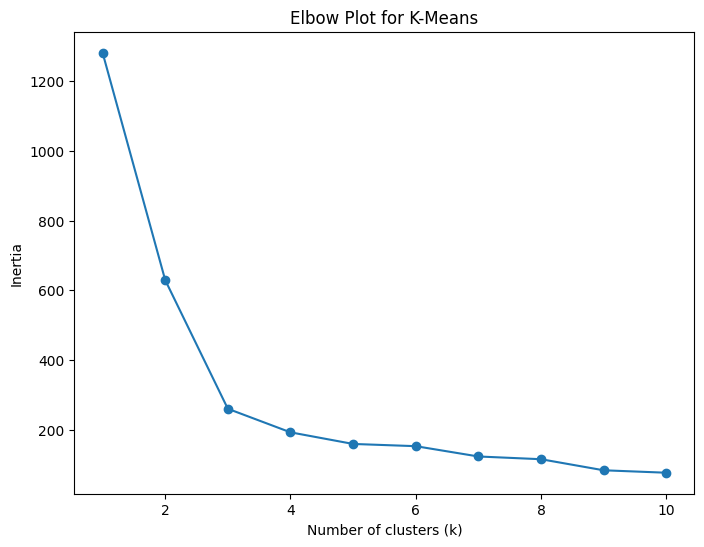

In [ ]:
inertia = []
K_range = range(1,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-Means")
plt.show()


The elbow plot shows a rapid decrease in inertia as k increases from 1 to 3, followed by a much slower rate of improvement for larger values of k. This change in slope indicates an elbow point at k = 3, suggesting that three clusters provide an optimal balance between clustering quality and model complexity. Adding more clusters beyond this point yields diminishing improvements in within-cluster compactness, making k = 3 a justified and efficient choice for k-means clustering (Geron, 2019).

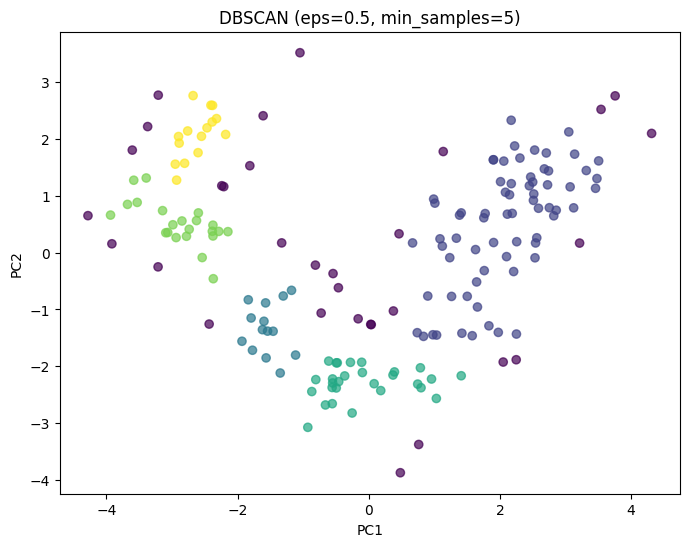

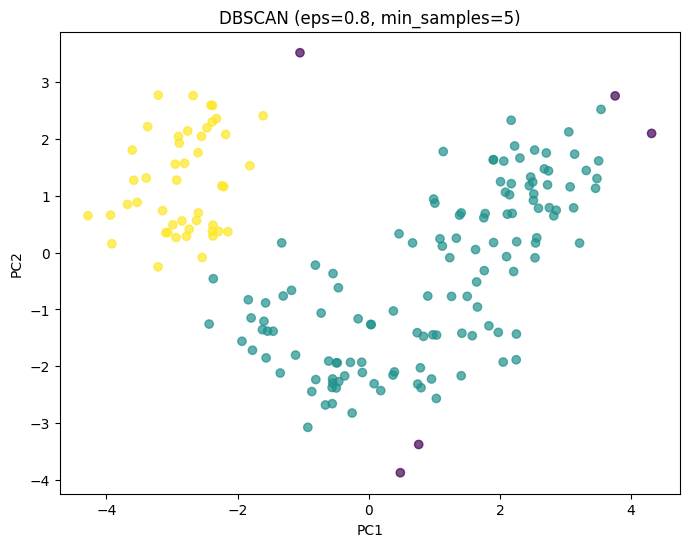

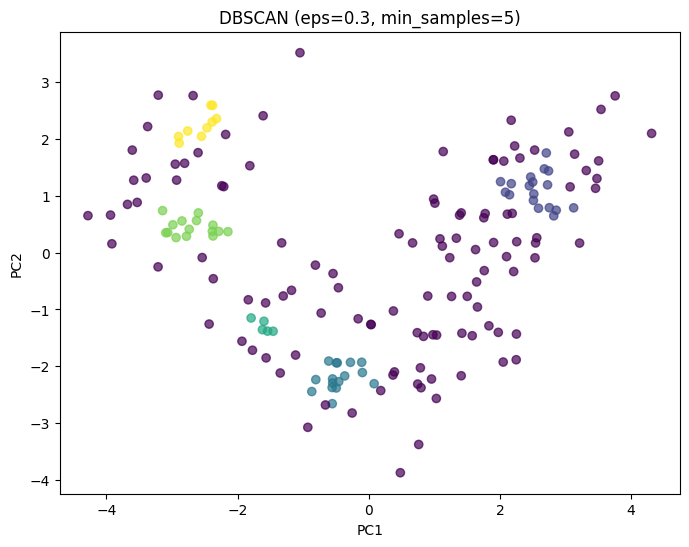

DBSCAN eps=0.5:
Clusters: 5 Noise points: 31

DBSCAN eps=0.8:
Clusters: 2 Noise points: 5

DBSCAN eps=0.3:
Clusters: 2 Noise points: 5


In [ ]:
#DBSCAN - Parameter Set 1

dbscan1 = DBSCAN(eps=0.5, min_samples=5)
db_labels1 = dbscan1.fit_predict(X_pca)

#DBSCAN - Parameter Set 2

dbscan2 = DBSCAN(eps=0.8, min_samples=5)
db_labels2 = dbscan2.fit_predict(X_pca)

#DBSCAN - Parameter Set 3

dbscan2 = DBSCAN(eps=0.3, min_samples=5)
db_labels3 = dbscan2.fit_predict(X_pca)

#Visualization 1

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels1, alpha=0.7)
plt.title("DBSCAN (eps=0.5, min_samples=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#Visualization 2

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels2, alpha=0.7)
plt.title("DBSCAN (eps=0.8, min_samples=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#Visualization 3

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels3, alpha=0.7)
plt.title("DBSCAN (eps=0.3, min_samples=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#Cluster counts and noise

def dbscan_stats(labels):
  clusters = len(set(labels)) - (1 if -1 in labels else 0)
  noise = np.sum(labels == -1)
  return clusters, noise

c1, n1 = dbscan_stats(db_labels1)
c2, n2 = dbscan_stats(db_labels2)
c3, n3 = dbscan_stats(db_labels2)

print("DBSCAN eps=0.5:")
print("Clusters:", c1, "Noise points:", n1)

print("\nDBSCAN eps=0.8:")
print("Clusters:", c2, "Noise points:", n2)

print("\nDBSCAN eps=0.3:")
print("Clusters:", c3, "Noise points:", n3)

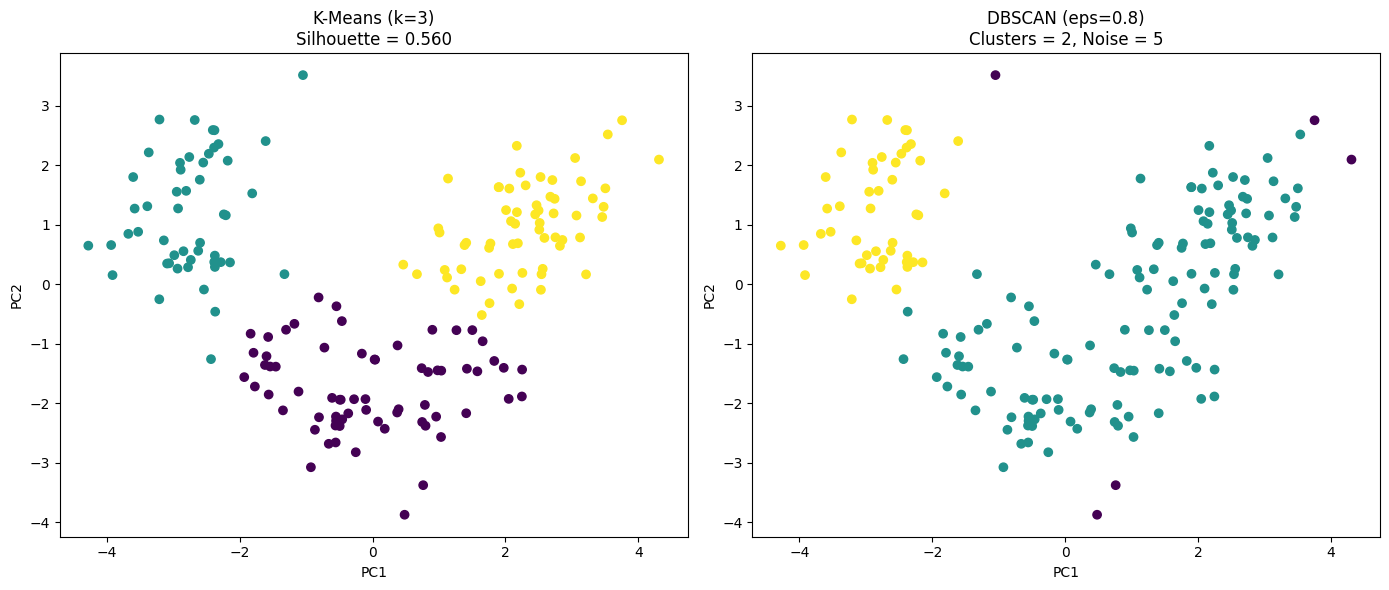

===== COMPARISON METRICS =====
K-Means silhouette score: 0.5602
DBSCAN clusters: 2
DBSCAN noise points: 5


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# ---------- KMEANS ----------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

kmeans_sil = silhouette_score(X_pca, kmeans_labels)

# ---------- DBSCAN ----------
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

# DBSCAN stats
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

# ---------- Visualization ----------
plt.figure(figsize=(14,6))

# KMeans plot
plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title(f"K-Means (k=3)\nSilhouette = {kmeans_sil:.3f}")
plt.xlabel("PC1")
plt.ylabel("PC2")

# DBSCAN plot
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title(f"DBSCAN (eps=0.8)\nClusters = {n_clusters}, Noise = {n_noise}")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

# ---------- Textual Comparison Metrics ----------
print("===== COMPARISON METRICS =====")
print(f"K-Means silhouette score: {kmeans_sil:.4f}")
print(f"DBSCAN clusters: {n_clusters}")
print(f"DBSCAN noise points: {n_noise}")

K-means grouped the wines cleanly into three meaningful groups, while DBSCAN struggled to find clear dense clusters and instead grouped the data into only two clusters and labeled some points as noise. This shows that K-means detects the underlying structure of the data better.

Clustering was performed on the two-dimensional PCA-reduced representation of the standardized Wine dataset to ensure consistent feature scaling and dimensional comparability. Principal Component Analysis (PCA) was applied to address multicollinearity and redundancy in the original feature space, compressing correlated variables into orthogonal components while preserving maximal variance (Jolliffe & Cadima, 2016). K-means clustering with k=3 produced a silhouette score of 0.5602, indicating strong intra-cluster cohesion and clear inter-cluster separation in the reduced feature space (Rousseeuw, 1987). This value reflects a well-structured partitioning in which observations are substantially closer to their assigned centroids than to competing cluster centroids, supporting the stability and interpretability of the clustering solution.

In contrast, DBSCAN identified only two clusters and classified five observations as noise, demonstrating limited density-based separability in the PCA-transformed space. DBSCAN relies on the presence of spatially isolated dense regions separated by low-density areas in order to form stable clusters (Ester et al., 1996). The observed clustering behavior indicates that such density discontinuities are weak or absent in the reduced feature space. Additionally, the sensitivity of DBSCAN to parameter selection (ε and min_samples) further highlights the lack of intrinsic density boundaries within the dataset.

The discrepancy between the two methods arises from their fundamentally different clustering assumptions. K-means optimizes centroid separation under Euclidean distance, making it well-suited for data exhibiting approximately convex, smoothly distributed cluster structures (MacQueen, 1967). DBSCAN, by contrast, is designed to detect arbitrarily shaped clusters defined by density connectivity rather than centroid proximity (Ester et al., 1996). The Wine dataset, after PCA transformation, exhibits continuous and overlapping distributions rather than distinct density-separated regions, limiting the effectiveness of density-based clustering.

Overall, these results demonstrate that K-means provides a more appropriate and robust clustering framework for this dataset, yielding stable, interpretable clusters, while DBSCAN’s density-based approach is constrained by the continuous and overlapping structure of observations in PCA space. This outcome reflects a structural compatibility between the dataset and centroid-based clustering assumptions, rather than a limitation of DBSCAN as a general algorithm.

# Citations

Dua, D., & Graff, C. (2019). Wine Data Set. UCI Machine Learning Repository. University of California, Irvine. https://archive.ics.uci.edu/ml/datasets/wine

Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). A density-based algorithm for discovering clusters in large spatial databases with noise. Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD-96), 226–231.

Geron, A. (2019). Hands-on machine learning with Scikit-Learn, Keras, and Tensorflow: Concepts, tools, and techniques to build intelligent systems (2nd ed.). O'Reilly Media, Inc.

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202

MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1(14), 281–297.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7



